### Usando os dados de kc_house_data

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Deixar toda a lógica do cálculo em uma célula separada e a lógica de plot do gráfico em outra célula

In [26]:
# 1. Leitura dos dados do arquivo CSV usando numpy
# Ignoramos a primeira linha (skip_header=1) pois ela contem os cabeçalhos 'x, y'"5. Regressão Linear.pdf"
dados = np.genfromtxt('kc_house_data.csv', delimiter=',', skip_header=1, usecols=(7, 2))
dados['floors'] = dados['floors'].astype(int)
x = dados[:, 0] # Variável Independente: sqft_living
y = dados[:, 1] #Variável Dependente: price
n = len(x)

# 2. Cálculo dos somatórios necessários para as fórmulas
sum_x = np.sum(x)
sum_y = np.sum(y)
sum_xy = np.sum(x * y)
sum_x2 = np.sum(x**2)
sum_y2 = np.sum(y**2)

# 3. Cálculo da Reta de Regressão (y_hat = a + b*x)
# Calculando o coeficiente 'b'
b = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)

# Calculando o coeficiente 'a'
a = (sum_y - b * sum_x) / n 

# Gerando os valores previstos (y_hat)
y_hat = a + b * x

# 4. Cálculo do Coeficiente de Correlação de Pearson (r)
numerador_r = n * sum_xy - (sum_x * sum_y)
denominador_r = np.sqrt(n * sum_x2 - sum_x**2) * np.sqrt(n * sum_y2 - sum_y**2)
r = numerador_r / denominador_r

# 5. Cálculo do Coeficiente de Determinação (R²)
y_mean = np.mean(y)
# Fórmula: Somatório de (y_hat - y_mean)² dividido pelo Somatório de (y - y_mean)²
sq_reg = np.sum((y_hat - y_mean)**2)
sq_tot = np.sum((y - y_mean)**2)
r2 = sq_reg / sq_tot

# 6. Exibição dos Resultados no Console
print(f"Equação da reta: ŷ = {a:.4f} + {b:.4f} * x")
print(f"Coeficiente de Correlação (r): {r:.4f}")
print(f"Coeficiente de Determinação (R²): {r2:.4f}")

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

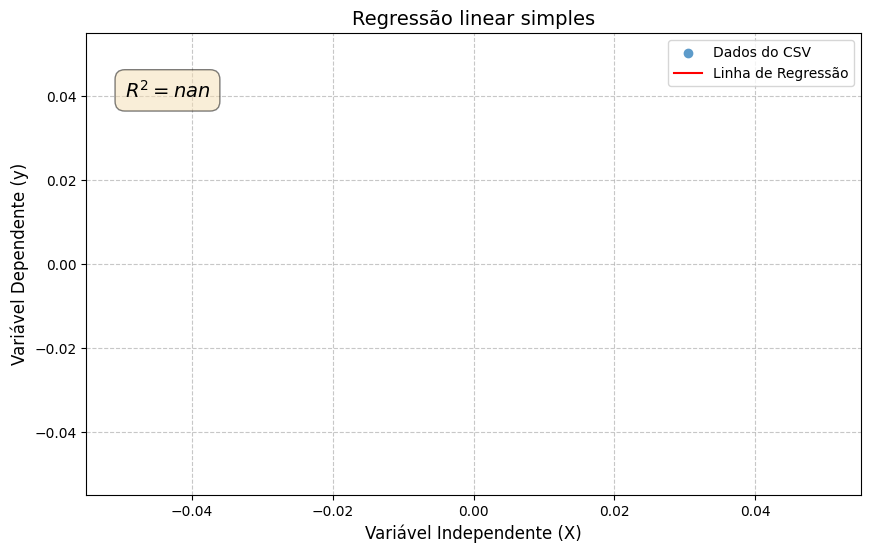

In [18]:
# 7. Visualização Gráfica dos Dados
plt.figure(figsize=(10, 6))

# Gráfico de dispersão (scatter plot) dos dados reais
plt.scatter(x, y, color='#5D9BCA', label='Dados do CSV')

# Linha de regressão gerada pelo modelo
plt.plot(x, y_hat, color='red', label='Linha de Regressão')

# Configurações de layout do gráfico
plt.title('Regressão linear simples', fontsize=14)
plt.xlabel('Variável Independente (X)', fontsize=12)
plt.ylabel('Variável Dependente (y)', fontsize=12)

# Adiciona o valor do R² ao gráficopara fácil visualização
plt.text(0.05, 0.9, f'$R^2 = {r2:.4f}$', transform=plt.gca().transAxes, 
         fontsize=14, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()